# Taller — Análisis exploratorio de variables categóricas y numéricas
### Versión SOLUCIÓN
### Dataset: `StudentsPerformance.csv`

## Paso 0 — Preparación

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Parte 1 — Variables categóricas

### Ejercicio 1.1 — Solución

In [20]:
print(df["gender"].value_counts())
print()
print(df["gender"].value_counts(normalize=True) * 100)

gender
female    518
male      482
Name: count, dtype: int64

gender
female    51.8
male      48.2
Name: proportion, dtype: float64


### Ejercicio 1.2 — Solución

In [21]:
print(df["test preparation course"].value_counts())
print()
print(df["test preparation course"].value_counts(normalize=True) * 100)

test preparation course
none         642
completed    358
Name: count, dtype: int64

test preparation course
none         64.2
completed    35.8
Name: proportion, dtype: float64


**Respuesta esperada — Pregunta de reflexión 1:** `gender` suele estar razonablemente balanceado (~48%/52%). `test preparation course` normalmente NO está balanceado (más estudiantes en `"none"` que en `"completed"`). Esto importa porque un grupo muy pequeño (por ejemplo, pocos `"completed"`) da comparaciones menos confiables/representativas al analizar diferencias de desempeño entre grupos.

> *Punto de discusión en clase:* preguntar "¿qué pasaría si quisiéramos comparar el promedio de notas entre quienes completaron el curso y quienes no, pero un grupo tiene 900 estudiantes y el otro 100?" — conecta con la idea de tamaño de muestra.

### Ejercicio 1.3 — Solución

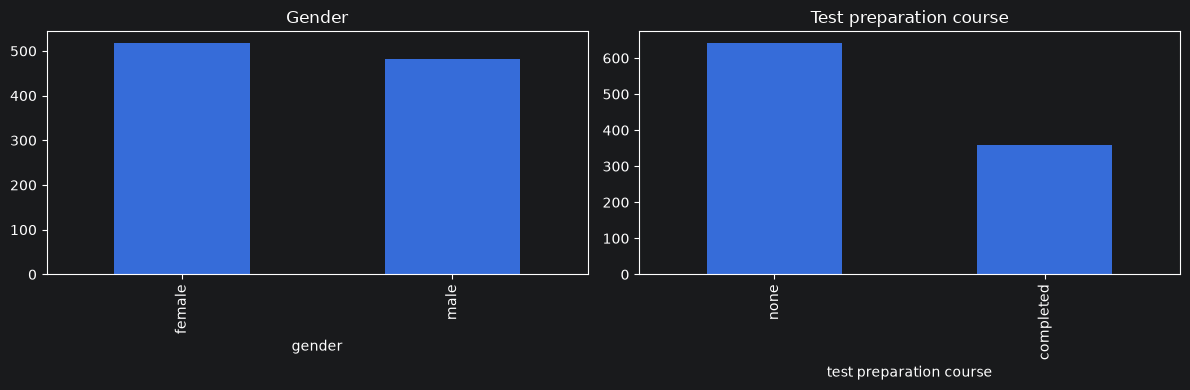

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["gender"].value_counts().plot(kind="bar", ax=axes[0], title="Gender")
df["test preparation course"].value_counts().plot(kind="bar", ax=axes[1], title="Test preparation course")

plt.tight_layout()
plt.show()

> *Error común:* olvidar `ax=axes[i]`, lo que genera dos figuras separadas en vez de un panel de dos gráficos.

## Parte 2 — Variables numéricas

### Ejercicio 2.1 — Solución

In [23]:
df["math score"].describe()

count    1000.00000
mean       66.08900
std        15.16308
min         0.00000
25%        57.00000
50%        66.00000
75%        77.00000
max       100.00000
Name: math score, dtype: float64

**Respuesta esperada — Pregunta de reflexión 2:** `mean` y `50%` (mediana) suelen ser muy parecidos (~66). Esto sugiere una distribución aproximadamente **simétrica**, sin sesgo fuerte hacia valores muy altos o muy bajos.

### Ejercicio 2.2 — Solución

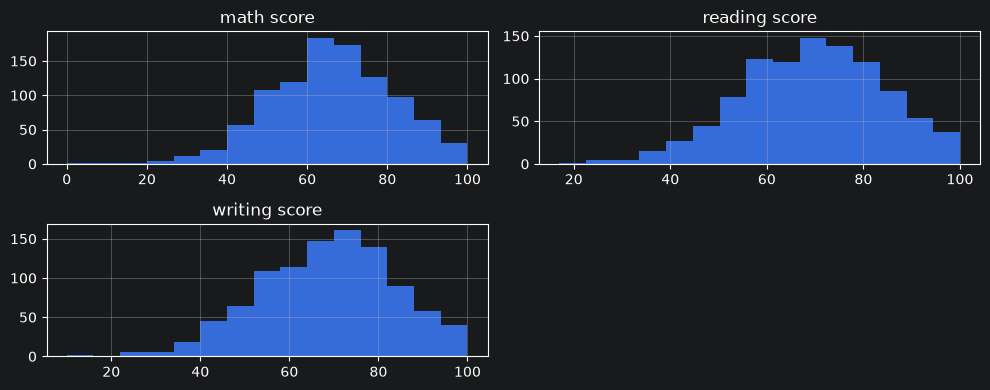

In [24]:
df[["math score", "reading score", "writing score"]].hist(figsize=(10, 4), bins=15)
plt.tight_layout()
plt.show()

**Respuesta esperada — Pregunta de reflexión 3:** Sí, las tres variables muestran una forma aproximada de campana (normal): pocas barras en los extremos, pico en el centro (alrededor de 60-75), y caída simétrica hacia ambos lados. Ninguna de las tres suele mostrar una asimetría marcada, aunque `math score` a veces muestra una cola ligeramente más marcada hacia valores bajos (algunos estudiantes con notas muy bajas, cercanas a 0).

> *Sugerencia de facilitación:* mostrar el diagrama de campana visto en la sesión anterior y pedir a los estudiantes que señalen en su propio histograma dónde estaría "la media/mediana" y dónde las "colas".

### Ejercicio 2.3 — Solución

In [25]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


**Respuesta esperada — Pregunta de reflexión 4:** Generalmente `math score` tiene la mayor dispersión (`std` más alto) y también suele tener el rango más amplio (mínimo más bajo, a veces 0). `reading score` y `writing score` tienden a estar más concentradas entre sí. Los valores exactos dependen de la versión del CSV, por lo que se recomienda verificar con la salida real antes de la clase.

## Parte 3 — Reto integrador (opcional) — Solución de referencia

In [26]:
df.groupby("lunch")["math score"].mean()

lunch
free/reduced    58.921127
standard        70.034109
Name: math score, dtype: float64

o alternativamente:

In [27]:
df.groupby("parental level of education")["math score"].mean().sort_values(ascending=False)

parental level of education
master's degree       69.745763
bachelor's degree     69.389831
associate's degree    67.882883
some college          67.128319
some high school      63.497207
high school           62.137755
Name: math score, dtype: float64

**Respuesta esperada — Pregunta de cierre:** Suele observarse que el grupo con `lunch = "standard"` tiene un promedio más alto en `math score` que el grupo con `"free/reduced"`. Es una buena oportunidad para introducir la diferencia entre **correlación y causalidad**: el dataset no permite concluir que el tipo de almuerzo *cause* el resultado — puede reflejar factores socioeconómicos subyacentes no capturados directamente en esta variable.

> *Cierre sugerido de la sesión:* recalcar que este taller cubre el análisis **descriptivo** (qué pasó, cómo se distribuyen los datos) — no predictivo ni causal — y que ese es el paso previo indispensable antes de cualquier modelo.

## Rúbrica rápida de participación (sugerida)

| Criterio | Logrado |
|---|---|
| Calcula frecuencias y porcentajes correctamente para 2 variables categóricas | ☐ |
| Interpreta correctamente el balance/desbalance de categorías | ☐ |
| Obtiene `describe()` e interpreta media vs. mediana | ☐ |
| Genera histogramas y reconoce (o descarta) la forma de campana | ☐ |
| Completa el reto integrador con `groupby` y propone una hipótesis razonable | ☐ |